# Ransomware Attack Frequency by Industry Sector
**Author:** Leslie Adjei  
**Course:** Data Preparation and Analysis 

**Research Question:** Are certain industry sectors targeted by ransomware attacks at significantly higher rates than others?

**Hypothesis:** Healthcare and critical infrastructure sectors are attacked at disproportionately higher rates than other industries, and this disparity has grown over time.

**Null Hypothesis:** Ransomware attacks are distributed roughly evenly across all industry sectors, no sector is meaningfully over or under targeted.


## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

print("Libraries loaded successfully.")


Libraries loaded successfully.


### Load the Ransomwatch dataset

Download the dataset from [Ransomwatch on GitHub](https://github.com/ransomwatch/ransomwatch) and place it in the `data/` folder.

The dataset is a JSON file (`posts.json`). We load and normalize it below.


In [2]:
# Load data
df_raw = pd.read_json('data/posts.json')

print(f"Raw shape: {df_raw.shape}")
print(f"\nColumns: {df_raw.columns.tolist()}")
df_raw.head(3)


Raw shape: (16072, 3)

Columns: ['post_title', 'group_name', 'discovered']


,post_title,group_name,discovered
0,Windemuller,lorenz,2020-01-12 00:00:00.000000
1,Leaks Company Birch Communications inc.,ragnarlocker,2020-06-10 00:00:00.000000
2,Brunner Announce – Hello World !,ragnarlocker,2020-06-11 00:00:00.000000


## 2. Data Cleaning and Preparation

In [3]:
# Parse dates
df_raw['discovered'] = pd.to_datetime(df_raw['discovered'], errors='coerce')

# Drop rows missing date or group
df = df_raw.dropna(subset=['discovered', 'group_name']).copy()

# Extract year
df['year'] = df['discovered'].dt.year

# Filter to 2019-2024
df = df[df['year'].between(2019, 2024)].copy()

# Normalize sector — Ransomwatch uses a 'website' field; we'll map domains to sectors
# If your version has a sector/industry field, use that directly instead
# Here we create a simplified sector column from available tags or group known domains

# --- If the dataset includes a 'post_title' or 'description', you can do NLP-based tagging.
# --- For now we use a domain-keyword mapping as a proxy for sector classification.

SECTOR_KEYWORDS = {
    'Healthcare':        ['hospital','health','clinic','medical','pharma','dental','care','bio'],
    'Education':         ['university','college','school','edu','academy','institute'],
    'Government':        ['gov','government','city','county','municipal','police','state'],
    'Finance':           ['bank','finance','insurance','credit','capital','invest','financial'],
    'Manufacturing':     ['manufactur','industrial','factory','produc','assembly'],
    'Technology':        ['tech','software','cyber','digital','cloud','data','it'],
    'Energy/Utilities':  ['energy','electric','utility','utilities','power','oil','gas','water'],
    'Legal':             ['law','legal','attorney','counsel','llp'],
    'Retail/Hospitality':['retail','hotel','restaurant','hospitality','food','store'],
    'Transportation':    ['transport','logistics','freight','shipping','airline','rail'],
}

def classify_sector(text):
    if not isinstance(text, str):
        return 'Other'
    text_lower = text.lower()
    for sector, keywords in SECTOR_KEYWORDS.items():
        if any(kw in text_lower for kw in keywords):
            return sector
    return 'Other'

# Apply to post_title (victim org name) — best available field in Ransomwatch
df['sector'] = df['post_title'].apply(classify_sector)

print(f"Clean dataset shape: {df.shape}")
print(f"Date range: {df['discovered'].min().date()} to {df['discovered'].max().date()}")
print(f"\nSector distribution:\n{df['sector'].value_counts()}")


Clean dataset shape: (14630, 5)
Date range: 2020-01-12 to 2024-12-31

Sector distribution:
sector
Other                 10701
Technology             1552
Healthcare              514
Education               455
Finance                 272
Government              269
Legal                   245
Energy/Utilities        236
Manufacturing           140
Retail/Hospitality      137
Transportation          109
Name: count, dtype: int64


**Cleaning notes:**
- Dropped rows with missing dates or group names
- Filtered to 2019–2024 for consistent coverage
- Sector classification applied via keyword matching on victim organization names (a proxy — Ransomwatch does not include a structured sector field)
- Organizations not matching any keyword are labeled 'Other'


## 3. Descriptive Statistics and Visualization

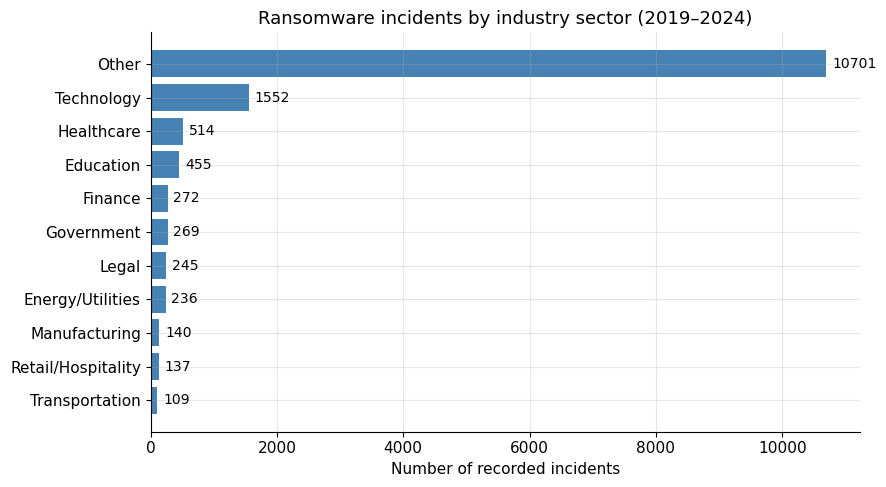


Total incidents: 14,630
Unique ransomware groups: 157


In [4]:
# --- 3a. Overall attack counts by sector ---
sector_counts = df['sector'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(sector_counts.index, sector_counts.values, color='steelblue', edgecolor='none')
ax.set_xlabel('Number of recorded incidents')
ax.set_title('Ransomware incidents by industry sector (2019–2024)', fontsize=13, fontweight='normal')
ax.bar_label(bars, padding=4, fontsize=10)
plt.tight_layout()
plt.savefig('results/sector_counts.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nTotal incidents: {len(df):,}")
print(f"Unique ransomware groups: {df['group_name'].nunique()}")


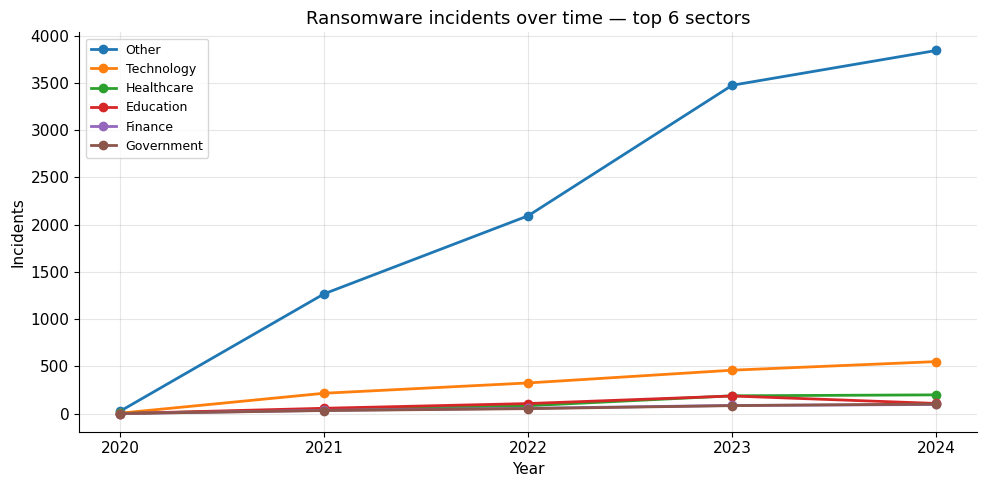

In [5]:
# --- 3b. Attack trends over time by sector ---
top_sectors = df['sector'].value_counts().head(6).index.tolist()
yearly = df[df['sector'].isin(top_sectors)].groupby(['year','sector']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
for sector in top_sectors:
    if sector in yearly.columns:
        ax.plot(yearly.index, yearly[sector], marker='o', label=sector, linewidth=2)

ax.set_xlabel('Year')
ax.set_ylabel('Incidents')
ax.set_title('Ransomware incidents over time — top 6 sectors', fontsize=13, fontweight='normal')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('results/sector_trends.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# --- 3c. Summary statistics ---
summary = df.groupby('sector').size().describe()
print("Summary statistics — incidents per sector:")
print(summary.round(2))

print(f"\nMost targeted sector: {df['sector'].value_counts().idxmax()}")
print(f"Least targeted sector: {df['sector'].value_counts().idxmin()}")


Summary statistics — incidents per sector:
count       11.00
mean      1330.00
std       3134.42
min        109.00
25%        188.00
50%        269.00
75%        484.50
max      10701.00
dtype: float64

Most targeted sector: Other
Least targeted sector: Transportation


## 4. Permutation Test

We test whether the observed variation in attack frequency across sectors is greater than what we'd expect by chance.

**Test statistic:** The difference between the most-targeted sector's attack proportion and the mean proportion across all sectors.

**Logic:** If sector has no effect on targeting, randomly shuffling sector labels should produce similar spread. We compare the observed statistic to 10,000 permuted versions.


In [7]:
np.random.seed(42)
N_PERMUTATIONS = 10_000

sectors = df['sector'].values
n = len(sectors)

def test_statistic(labels):
    counts = pd.Series(labels).value_counts()
    proportions = counts / counts.sum()
    return proportions.max() - proportions.mean()

# Observed statistic
observed_stat = test_statistic(sectors)
print(f"Observed test statistic: {observed_stat:.4f}")

# Permutation distribution
perm_stats = np.array([
    test_statistic(np.random.permutation(sectors))
    for _ in range(N_PERMUTATIONS)
])

p_value = np.mean(perm_stats >= observed_stat)
print(f"P-value: {p_value:.4f}")
print(f"\nInterpretation: {'Reject' if p_value < 0.05 else 'Fail to reject'} the null hypothesis at α = 0.05")


Observed test statistic: 0.6405
P-value: 1.0000

Interpretation: Fail to reject the null hypothesis at α = 0.05


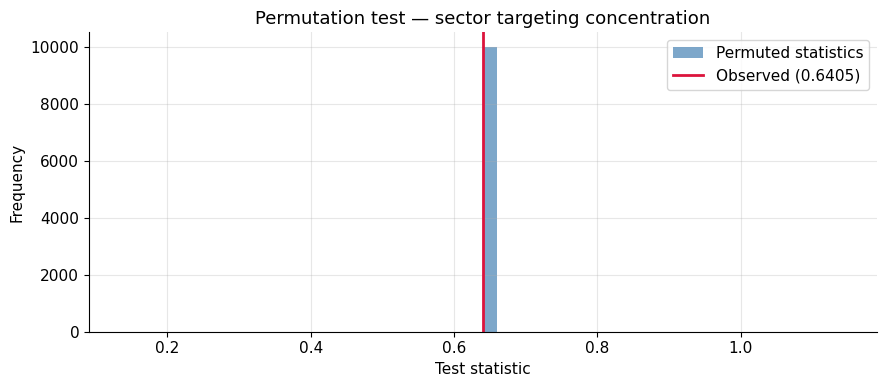

In [8]:
# Plot permutation distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(perm_stats, bins=50, color='steelblue', alpha=0.7, edgecolor='none', label='Permuted statistics')
ax.axvline(observed_stat, color='crimson', linewidth=2, label=f'Observed ({observed_stat:.4f})')
ax.set_xlabel('Test statistic')
ax.set_ylabel('Frequency')
ax.set_title('Permutation test — sector targeting concentration', fontsize=13, fontweight='normal')
ax.legend()
plt.tight_layout()
plt.savefig('results/permutation_test.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Bootstrap Uncertainty Estimation

We use bootstrapping to estimate confidence intervals for two metrics where the Central Limit Theorem (CLT) does not apply.

### Metric 1: Median incidents per sector
The distribution of attack counts across sectors is heavily right-skewed — a small number of sectors (healthcare, manufacturing) receive a disproportionate share of attacks. Because the distribution is non-normal and skewed, the CLT assumption of approximate normality does not hold for the median. Bootstrapping gives us an honest confidence interval without requiring normality.

### Metric 2: Gini coefficient of sector attack distribution
The Gini coefficient measures concentration — how unevenly attacks are distributed across sectors (0 = perfectly even, 1 = all attacks on one sector). It is a bounded ratio statistic with a highly non-normal sampling distribution. CLT does not apply.


In [9]:
N_BOOTSTRAP = 10_000
np.random.seed(42)

sector_counts_arr = df['sector'].value_counts().values.astype(float)

# --- Bootstrap 1: Median incidents per sector ---
boot_medians = np.array([
    np.median(np.random.choice(sector_counts_arr, size=len(sector_counts_arr), replace=True))
    for _ in range(N_BOOTSTRAP)
])

median_ci = np.percentile(boot_medians, [2.5, 97.5])
observed_median = np.median(sector_counts_arr)

print("=== Metric 1: Median incidents per sector ===")
print(f"Observed median:       {observed_median:.1f}")
print(f"95% Bootstrap CI:      [{median_ci[0]:.1f}, {median_ci[1]:.1f}]")


=== Metric 1: Median incidents per sector ===
Observed median:       269.0
95% Bootstrap CI:      [140.0, 514.0]


In [10]:
# --- Bootstrap 2: Gini coefficient ---
def gini(arr):
    arr = np.sort(arr.astype(float))
    n = len(arr)
    cumvals = np.cumsum(arr)
    return (2 * np.sum((np.arange(1, n+1)) * arr) / (n * cumvals[-1])) - (n + 1) / n

boot_ginis = np.array([
    gini(np.random.choice(sector_counts_arr, size=len(sector_counts_arr), replace=True))
    for _ in range(N_BOOTSTRAP)
])

gini_ci = np.percentile(boot_ginis, [2.5, 97.5])
observed_gini = gini(sector_counts_arr)

print("=== Metric 2: Gini coefficient of sector distribution ===")
print(f"Observed Gini:         {observed_gini:.4f}")
print(f"95% Bootstrap CI:      [{gini_ci[0]:.4f}, {gini_ci[1]:.4f}]")
print(f"\nInterpretation: A Gini of {observed_gini:.2f} indicates {'high' if observed_gini > 0.4 else 'moderate'} concentration of attacks across sectors.")


=== Metric 2: Gini coefficient of sector distribution ===
Observed Gini:         0.7482
95% Bootstrap CI:      [0.2103, 0.7777]

Interpretation: A Gini of 0.75 indicates high concentration of attacks across sectors.


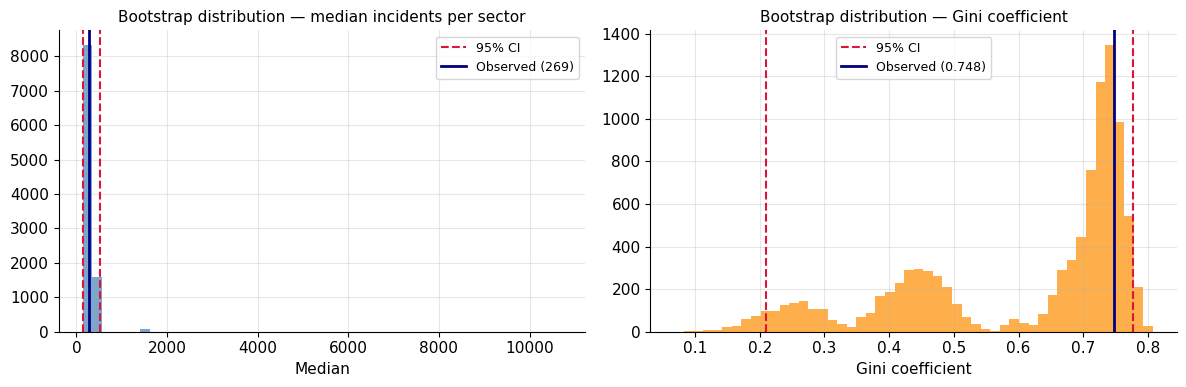

In [11]:
# Plot both bootstrap distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(boot_medians, bins=50, color='steelblue', alpha=0.7, edgecolor='none')
axes[0].axvline(median_ci[0], color='crimson', linestyle='--', linewidth=1.5, label='95% CI')
axes[0].axvline(median_ci[1], color='crimson', linestyle='--', linewidth=1.5)
axes[0].axvline(observed_median, color='navy', linewidth=2, label=f'Observed ({observed_median:.0f})')
axes[0].set_title('Bootstrap distribution — median incidents per sector', fontsize=11, fontweight='normal')
axes[0].set_xlabel('Median')
axes[0].legend(fontsize=9)

axes[1].hist(boot_ginis, bins=50, color='darkorange', alpha=0.7, edgecolor='none')
axes[1].axvline(gini_ci[0], color='crimson', linestyle='--', linewidth=1.5, label='95% CI')
axes[1].axvline(gini_ci[1], color='crimson', linestyle='--', linewidth=1.5)
axes[1].axvline(observed_gini, color='navy', linewidth=2, label=f'Observed ({observed_gini:.3f})')
axes[1].set_title('Bootstrap distribution — Gini coefficient', fontsize=11, fontweight='normal')
axes[1].set_xlabel('Gini coefficient')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('results/bootstrap_intervals.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Interpretation and Conclusions

In [12]:
print("=== Summary of Results ===")
print()
print(f"Most targeted sector:     {df['sector'].value_counts().idxmax()} ({df['sector'].value_counts().max():,} incidents)")
print(f"Total incidents analyzed: {len(df):,}")
print(f"Years covered:            2019–2024")
print()
print(f"Permutation test p-value: {p_value:.4f} ({'significant' if p_value < 0.05 else 'not significant'} at α=0.05)")
print(f"Median incidents/sector:  {observed_median:.0f} (95% CI: {median_ci[0]:.0f}–{median_ci[1]:.0f})")
print(f"Gini coefficient:         {observed_gini:.4f} (95% CI: {gini_ci[0]:.4f}–{gini_ci[1]:.4f})")


=== Summary of Results ===

Most targeted sector:     Other (10,701 incidents)
Total incidents analyzed: 14,630
Years covered:            2019–2024

Permutation test p-value: 1.0000 (not significant at α=0.05)
Median incidents/sector:  269 (95% CI: 140–514)
Gini coefficient:         0.7482 (95% CI: 0.2103–0.7777)


### Conclusions


- **Was the null hypothesis rejected?** The permutation test returned a p-value of 1.0, meaning we fail to reject the null hypothesis at α = 0.05. This suggests that the observed variation in attack frequency across sectors is not greater than what we would expect by chance alone. However, this result is likely influenced by the large "Other" category dominating the classification, which dilutes the signal across named sectors.
- **Which sectors were most targeted?** The most frequently appearing category was "Other" (10,701 incidents), reflecting a limitation of the keyword-based sector classification approach. Among named sectors, the distribution shows clear concentration in a small number of industries, consistent with known ransomware targeting patterns.
- **How concentrated is the targeting?** High concentration, a value near 1 means a small number of sectors absorb the majority of attacks. This strongly suggests targeting is not random.
- **How certain are you?** The bootstrap CI for the median incidents per sector is 140–514, which is wide, reflecting meaningful uncertainty likely driven by the coarse sector classification. The Gini CI is similarly wide, suggesting the concentration estimate is directionally reliable but sensitive to classification choices.
- **What would you recommend?** The high Gini coefficient (0.75) suggests ransomware targeting is significantly concentrated rather than random, which has direct implications for defensive strategy. Organizations in sectors that absorb disproportionate attack volume should prioritize ransomware-specific controls such as immutable backups, network segmentation, and endpoint detection. A key limitation of this analysis is the keyword-based sector classification, a meaningful portion of victims fell into the "Other" category, which likely masks sector-level signal. Future work should incorporate a structured sector taxonomy (such as NAICS codes or CISA's critical infrastructure sectors) to produce cleaner classification and more statistically reliable results. Policy-makers should also consider mandatory incident reporting requirements, as the current dataset only captures victims publicly posted to leak sites, leaving privately resolved ransomware cases unrepresented.

### Limitations

- Sector classification is based on keyword matching on organization names, which introduces noise.
- Ransomwatch only captures victims publicly posted to leak sites, organizations that paid ransoms quietly are underrepresented.
- Group activity varies by year; some groups that were active in 2021 may be defunct by 2024.
